In [2]:
from classy import Class

import os
import copy
import yaml
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

from matplotlib import rc
from scipy.interpolate import interp1d

rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)
#matplotlib.rc('font', **font)
matplotlib.rcParams['legend.fontsize']='medium'
plt.rcParams["figure.figsize"] = [8.0,6.0]

# warmup

run a fiducial cosmology

In [3]:
LCDM =  Class()
baseline = {'omega_b':0.0223828,
            'omega_cdm':0.3,
            'h':0.67810,'A_s':2.100549e-09,
            'n_s':0.9660499,
            'tau_reio':0.05430842, 
#            'lensing':'yes',
#            'output': 'tCl,pCl,lCl',
            'input_verbose': 20,
#            'output_verbose': 10,
            'background_verbose': 20
            }
LCDM.set(baseline)

True

In [4]:
#EDE_common_dict = {
    #'Omega_scf':Omega_scf,
    #'m_axion':m_axion,
    #'f_axion':f_axion,
    #'scf_parameters': r'%g, %g' % (0.05, 0.),
    #'scf_parameters__2': 0., 
    #'n_axion': 1, 
    #'scf_has_perturbations': 'yes', 
    #'scf_tuning_index': 0,
    #'tol_shooting_deltax':1e-4,
    #'tol_shooting_deltaF':1e-4,
    #'thermodynamics_verbose':1, 
#    }

# EDE1 is one axion EDE
# EDEm is m = many, and i want to check for m = 1 first

EDE1 = Class()
EDEm = Class()

m_axion = 1e8
f_axion = 0.4
Omega_scf = 0.05
params = (2.72,0.)

#EDE1.set(baseline)
EDE1.set({
    'Omega_cdm':0.3,
    'H0':67,
    'Omega_scf':Omega_scf,
    'm_axion':m_axion,
    'f_axion':f_axion,
    'scf_parameters': r'%g, %g' % (0.05, 0.),
    #'scf_parameters__2': 0., 
    'scf_potential': 'axion', 
    'n_axion': 1, 
    'scf_has_perturbations': 'yes', 
    'attractor_ic_scf': 'no',
    'do_shooting': 'yes',
    'do_shooting_scf': 'yes',
    'scf_tuning_index': 0,
    'tol_shooting_deltax':1e-4,
    'tol_shooting_deltaF':1e-4,
    'background_verbose':10,
    'thermodynamics_verbose':1,
    'scf_evolve_as_fluid':'yes',
    'scf_evolve_like_axionCAMB':'yes',
    'm_axion': m_axion,
    'f_axion': f_axion,
    'Omega_scf': Omega_scf,
    })
EDE1.set({'output': 'mPk', 'z_max_pk': 1, 'P_k_max_h/Mpc': 1.})


#EDEm.set(baseline)
#EDEm.set({'N_mscf': 1,
#    'm_mscf':'1e8',
#    'f_axion_mscf':'0.4',
#    'mscf_potential': 'axion', 
#    'n_axion_mscf': '2.6', 
#    'phi_ini_mscf': '2.72',
#    'phi_prime_ini_mscf': '0.', #idk why axiclass doesn't want this but yeaaaaa
#    'scf_potential':'axion',
#    'Neff':'3.046'
#    'useless_parameter':'crap',
#    })



#ADE1.set({'ede_parametrization': 'pheno_axion_p',})
#ADE2.set({'ede_parametrization': 'pheno_axion',})


True

In [5]:
#LCDM.compute()
EDE1.compute()
#EDEm.compute()

#ADE1.get_background()
#ADE2.get_background()

xwero 2.515202e-01
Running CLASS version v3.3.0
Computing background
Chose ndf15 as generic_evolver
 -> age = 12.967267 Gyr
 -> conformal age = 12951.910148 Mpc
 -> H0 = 67.000000 km/s/Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
    Scalar field details:
     -> Omega_scf = 0.05, wished 0.05
Additional scf parameters used: 
n = 1.000000e+00 m_a = 1.429134e-25 eV, f_a/mpl = 4.000000e-01
     -> theta_ini = 2.515202e-01 	 phi_ini = 1.006081e-01 
     -> Exact log10(z_c) = 1.033237e+00 	 f_ede = 1.249554e-01 log10 f_ede = -9.032449e-01
     -> phi(z_c) = 6.025064e-02 
     -> Omega_Lambda = 0.601229, wished 0.601229
 -> radiation/matter equality at z = 4277.842204
    corresponding to conformal time = 89.756835 Mpc
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Omega = 0.0486773       , omega = 0.0218513      
-> Cold Dark Matter               Omega = 0.3 

In [6]:
bg1 = EDE1.get_background()
#bg_m = EDEm.get_background()
print(bg1.keys())
derived = EDE1.get_current_derived_parameters(['z_eq','z_rec'])

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_scf', '(.)Omega_scf', '(.)p_scf', '(.)p_prime_scf', '(.)w_scf', '(.)dw_scf', 'phi_scf', "phi'_scf", 'V_scf', "V'_scf", "V''_scf", '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])


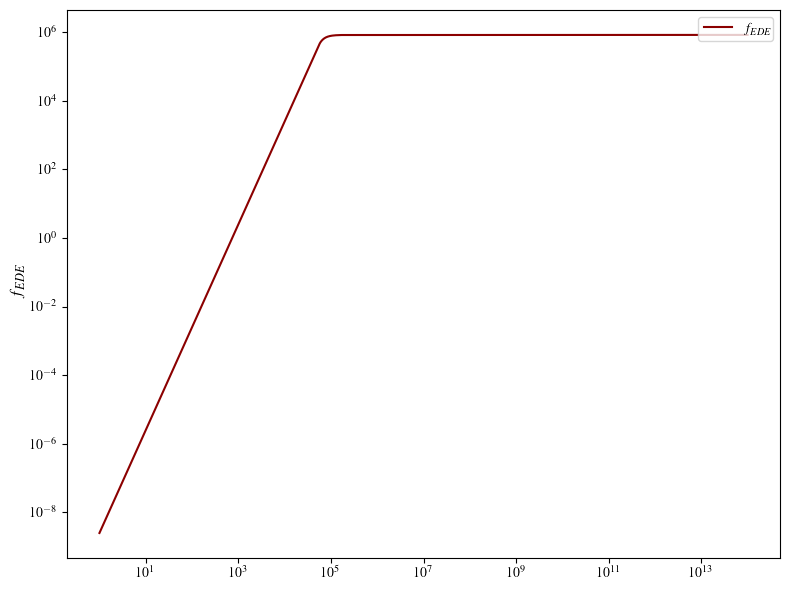

In [9]:
# Prepare the data
z = bg1['z']
z_eq = derived['z_eq']
z_rec = derived['z_rec']
#w_fld_EDE1 = bg1['(.)w_fld']
#w_fld_EDEm = bg_m['(.)w_fld']
rho_EDE1 = bg1['(.)rho_scf']
rho_tot_EDE1 = bg1['(.)rho_tot']
f_1 = rho_EDE1 / rho_tot_EDE1  # This will go on the right-hand y-axis

#rho_EDEm = bg_m['(.)rho_fld']
#rho_tot_EDEm = bg_m['(.)rho_tot']
#f_m = rho_EDEm / rho_tot_EDEm  # This will go on the right-hand y-axis
fig, ax = plt.subplots()
ax.plot(1+z, rho_EDE1, label=r'$f_{EDE}$', color='darkred')
#ax.plot(z, f_m, label=r'$f_{mEDE}$', color='darkblue')
ax.set_xlabel(r'$1+z$',fontsize='large')
ax.set_ylabel(r'$f_{EDE}$',fontsize='large')
#ax.set_ylim(0, .1)  # Set based on physical expectations
#ax.tick_params(colors='darkred')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper right', bbox_to_anchor=(1, 1))
ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

In [8]:
EDE1.empty()
#EDEm.empty()